<a href="https://colab.research.google.com/github/moiraclavin/infovis/blob/main/notebooks/Examen1-An%C3%A1lisisPredictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo — Examen 1
## Predicción de emisiones de CO₂ per cápita por país
**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions  
**Fuente:** github.com/owid/co2-data  
**Grupo:** Ramón Eppens · Moira Patricia Clacin · María Belen Piuma Justo

**ITBA — 2026**

In [43]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual general
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("Librerías cargadas correctamente. ")

Librerías cargadas correctamente. 


In [44]:
# === CARGA DEL DATASET ===
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado correctamente.
Dimensiones: 50,411 filas × 79 columnas


In [85]:
# === PRIMER VISTAZO ===
df.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
50401,Zimbabwe,2015,ZWE,14399008.0,2.424616e+10,0.585,0.041,12.017,0.071,0.591,...,NaN,0.111,0.001,0.001,0.002,0.0,31.410,17.956,1.296,10.782
50402,Zimbabwe,2016,ZWE,14600297.0,2.436205e+10,0.461,0.032,10.588,-1.429,-11.888,...,NaN,0.110,0.001,0.001,0.002,0.0,26.044,16.069,2.651,25.033
50403,Zimbabwe,2017,ZWE,14812484.0,2.557601e+10,0.469,0.032,9.831,-0.758,-7.156,...,NaN,0.109,0.001,0.001,0.002,0.0,30.901,15.621,1.222,12.426
50404,Zimbabwe,2018,ZWE,15034457.0,2.678627e+10,0.558,0.037,11.209,1.379,14.024,...,NaN,0.108,0.001,0.001,0.002,0.0,27.250,17.198,1.142,10.187
50405,Zimbabwe,2019,ZWE,15271377.0,2.514642e+10,0.473,0.031,10.267,-0.942,-8.408,...,NaN,0.107,0.001,0.001,0.002,0.0,30.672,16.218,1.360,13.245
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957
50410,Zimbabwe,2024,ZWE,16634366.0,NaN,0.387,0.023,13.701,0.258,1.918,...,NaN,0.102,0.001,0.001,0.002,0.0,31.066,20.773,NaN,NaN


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [47]:
# Tipos de datos por columna
df.dtypes.value_counts()

,count
float64,76
object,2
int64,1


## 1. Descripción general del dataset

In [48]:
# === DIMENSIONES Y TIPOS DE DATOS ===
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

Filas:    50,411
Columnas: 79

Tipos de datos:
float64    76
object      2
int64       1
Name: count, dtype: int64


In [49]:
# === INFO GENERAL ===
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

### 1.1 Estadísticas descriptivas

In [50]:
# === ESTADÍSTICAS DESCRIPTIVAS ===
# Solo columnas numéricas, redondeado a 2 decimales
df.describe().round(2)

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.00,4.116700e+04,1.525100e+04,29173.00,25648.00,29384.00,27216.00,26239.00,23796.00,23496.00,...,2170.00,41238.00,38280.00,41238.00,41238.00,38280.00,38150.00,37813.00,4712.00,4712.00
mean,1920.35,6.017453e+07,3.300495e+11,7.89,0.06,420.23,6.27,42.60,544.14,7.48,...,7.19,2.27,0.00,0.01,0.01,0.00,490.80,310.52,-6.99,21.47
std,65.86,3.308433e+08,3.086383e+12,62.99,0.12,1972.09,62.20,1721.91,2273.28,99.51,...,17.45,9.28,0.02,0.05,0.06,0.00,2414.08,1812.36,259.02,62.64
min,1750.00,2.150000e+02,4.998000e+07,0.00,0.00,0.00,-1928.34,-100.00,-84.56,-2298.98,...,0.00,-0.82,-0.00,0.00,-0.00,0.00,-19.73,0.00,-2177.81,-98.28
25%,1875.00,3.272140e+05,7.874038e+09,0.00,0.00,0.38,-0.00,-1.07,6.67,-0.73,...,0.14,0.00,0.00,0.00,0.00,0.00,1.50,0.22,-2.26,-6.83
50%,1925.00,2.291594e+06,2.743861e+10,0.00,0.00,5.08,0.04,3.81,28.12,0.11,...,0.59,0.08,0.00,0.00,0.00,0.00,14.61,2.22,1.64,8.38
75%,1975.00,9.986553e+06,1.212627e+11,0.52,0.08,53.66,1.02,10.88,124.30,2.77,...,2.42,0.37,0.00,0.00,0.00,0.00,76.51,27.86,11.43,32.78
max,2024.00,8.161973e+09,1.301126e+14,1666.88,2.48,38598.58,1804.66,180870.00,43184.09,2614.87,...,100.00,100.00,0.38,1.22,1.68,0.08,54433.40,43714.78,1768.85,1023.04


### 1.2 Valores faltantes

Columnas con valores faltantes: 77 de 79
Columnas sin ningún nulo:       2



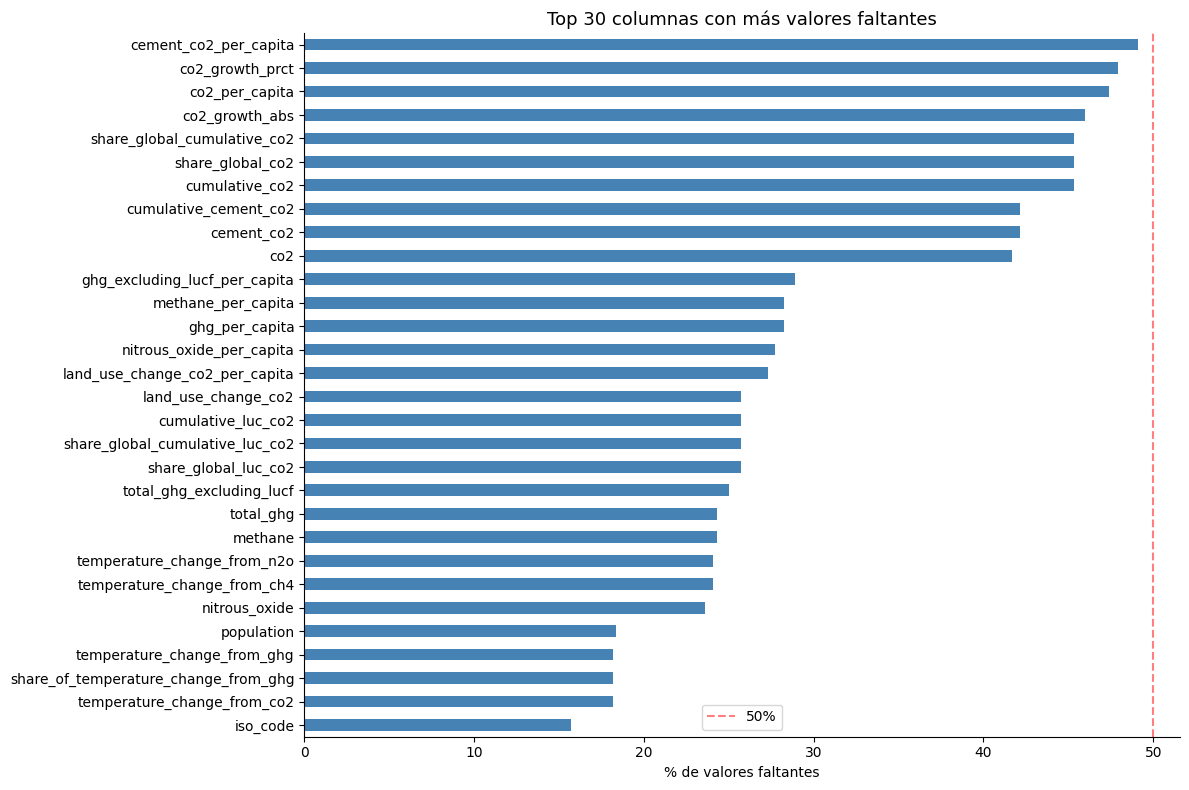

In [51]:
# === VALORES FALTANTES ===
# Calcular % de nulos por columna
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]  # Solo columnas con al menos un nulo

print(f"Columnas con valores faltantes: {len(missing)} de {df.shape[1]}")
print(f"Columnas sin ningún nulo:       {df.shape[1] - len(missing)}\n")

# Graficar las 30 columnas con más nulos
fig, ax = plt.subplots(figsize=(12, 8))
missing.sort_values(ascending=True).head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 30 columnas con más valores faltantes', fontsize=13)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Cobertura temporal y geográfica

In [52]:
# === COBERTURA TEMPORAL Y GEOGRÁFICA ===
print(f"Rango de años: {df['year'].min()} — {df['year'].max()}")
print(f"Países/regiones únicos: {df['country'].nunique()}")
print(f"\nPrimeros y últimos años con datos:")
print(df.groupby('year')['country'].count().head(5).to_string())
print("...")
print(df.groupby('year')['country'].count().tail(5).to_string())

Rango de años: 1750 — 2024
Países/regiones únicos: 254

Primeros y últimos años con datos:
year
1750    58
1751    58
1752    58
1753    58
1754    58
...
year
2020    254
2021    254
2022    254
2023    254
2024    254


In [53]:
# === IDENTIFICAR AGREGADOS REGIONALES ===
# OWID incluye no solo países sino también regiones agregadas
# (ej: "World", "Asia", "Europe") — hay que identificarlos para filtrarlos después

# Los agregados no tienen código ISO de 3 letras
aggregates = df[df['iso_code'].isna()]['country'].unique()
print(f"Agregados regionales encontrados ({len(aggregates)}):")
for a in sorted(aggregates):
    print(f"  - {a}")

Agregados regionales encontrados (36):
  - Africa
  - Africa (GCP)
  - Asia
  - Asia (GCP)
  - Asia (excl. China and India)
  - Central America (GCP)
  - Europe
  - Europe (GCP)
  - Europe (excl. EU-27)
  - Europe (excl. EU-28)
  - European Union (27)
  - European Union (28)
  - High-income countries
  - International aviation
  - International shipping
  - Kosovo
  - Kuwaiti Oil Fires
  - Kuwaiti Oil Fires (GCP)
  - Least developed countries (Jones et al.)
  - Low-income countries
  - Lower-middle-income countries
  - Middle East (GCP)
  - Non-OECD (GCP)
  - North America
  - North America (GCP)
  - North America (excl. USA)
  - OECD (GCP)
  - OECD (Jones et al.)
  - Oceania
  - Oceania (GCP)
  - Ryukyu Islands
  - Ryukyu Islands (GCP)
  - South America
  - South America (GCP)
  - Upper-middle-income countries
  - World


## 2. Filtros y limpieza

### 2.1 Eliminar agregados regionales

In [54]:
# === ELIMINAR AGREGADOS REGIONALES ===
# Nos quedamos solo con países reales (los que tienen código ISO)
df_countries = df[df['iso_code'].notna()].copy()

print(f"Dataset original:  {df.shape[0]:,} filas · {df['country'].nunique()} entidades")
print(f"Solo países:       {df_countries.shape[0]:,} filas · {df_countries['country'].nunique()} países")
print(f"Filas eliminadas:  {df.shape[0] - df_countries.shape[0]:,}")

Dataset original:  50,411 filas · 254 entidades
Solo países:       42,480 filas · 218 países
Filas eliminadas:  7,931


### 2.2 Filtro temporal: 1990–2024

In [55]:
# === FILTRO TEMPORAL ===
# Pre-1990: muy pocos países reportan datos completos
# Post-2022: datos incompletos (lag de publicación)
df_clean = df_countries[
    (df_countries['year'] >= 1990) &
    (df_countries['year'] <= 2024)
].copy()

print(f"Con filtro temporal: {df_clean.shape[0]:,} filas")
print(f"Años cubiertos:      {df_clean['year'].min()} — {df_clean['year'].max()}")
print(f"Países:              {df_clean['country'].nunique()}")

Con filtro temporal: 7,630 filas
Años cubiertos:      1990 — 2024
Países:              218


In [56]:
df_clean.describe().round(2)

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,7630.0,7.560000e+03,5.410000e+03,7264.00,7194.00,7508.00,7495.00,7445.00,6777.00,6768.00,...,1610.00,7525.00,7035.00,7525.00,7525.00,7035.00,6965.00,6908.00,4063.00,4063.00
mean,2007.0,3.130453e+07,4.894066e+11,5.19,0.11,137.54,2.10,3.59,184.91,2.09,...,2.17,0.47,0.00,0.00,0.01,0.00,231.85,175.73,-0.07,25.79
std,10.1,1.253046e+08,1.704830e+12,37.83,0.16,675.29,31.95,30.11,740.48,56.96,...,7.22,1.68,0.00,0.02,0.02,0.00,877.38,789.62,113.99,65.88
min,1990.0,5.010000e+02,2.571720e+08,0.00,0.00,0.00,-545.96,-100.00,-84.56,-1723.48,...,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-1604.43,-98.28
25%,1998.0,6.340445e+05,1.885143e+10,0.00,0.00,0.85,-0.09,-2.28,4.94,-1.72,...,0.10,0.01,0.00,0.00,0.00,0.00,8.28,3.07,-1.01,-5.21
50%,2007.0,5.520324e+06,6.108450e+10,0.32,0.04,7.17,0.02,1.90,28.43,0.00,...,0.30,0.08,0.00,0.00,0.00,0.00,43.86,16.67,1.96,12.31
75%,2016.0,2.003905e+07,2.913226e+11,1.79,0.15,53.94,0.71,6.89,86.88,2.03,...,1.03,0.26,0.00,0.00,0.00,0.00,122.43,74.48,10.20,37.33
max,2024.0,1.450936e+09,2.696602e+13,828.71,1.46,12289.04,910.11,1550.84,11969.62,1815.36,...,46.56,21.13,0.05,0.25,0.30,0.01,14107.01,13698.57,573.60,1023.04


In [57]:
resumen = pd.DataFrame({
    'columna': df_clean.columns,
    'nulos': df_clean.isnull().sum().values,
    'ceros': (df_clean == 0).sum().values
})

resumen['% nulos'] = (resumen['nulos'] / len(df_clean)) * 100
resumen['% ceros'] = (resumen['ceros'] / len(df_clean)) * 100

resumen.sort_values(by='% nulos', ascending=False)

,columna,nulos,ceros,% nulos,% ceros
49,other_co2_per_capita,6020,34,78.899083,0.445609
69,share_global_other_co2,6020,60,78.899083,0.786370
64,share_global_cumulative_other_co2,6020,71,78.899083,0.930537
50,other_industry_co2,6020,44,78.899083,0.576671
32,cumulative_other_co2,6020,35,78.899083,0.458716
...,...,...,...,...,...
72,temperature_change_from_co2,105,3492,1.376147,45.766710
3,population,70,0,0.917431,0.000000
0,country,0,0,0.000000,0.000000
1,year,0,0,0.000000,0.000000


In [58]:
threshold = 50  # porcentaje

resumen = pd.DataFrame({
    'nulos': df_clean.isnull().sum(),
    'ceros': (df_clean == 0).sum()
})

resumen['% nulos'] = (resumen['nulos'] / len(df_clean)) * 100
resumen['% ceros'] = (resumen['ceros'] / len(df_clean)) * 100

# Filtrar columnas problemáticas
columnas_problematicas = resumen[
    (resumen['% nulos'] > threshold) | (resumen['% ceros'] > threshold)
].sort_values(by='% nulos', ascending=False)

columnas_problematicas

,nulos,ceros,% nulos,% ceros
cumulative_other_co2,6020,35,78.899083,0.458716
other_co2_per_capita,6020,34,78.899083,0.445609
share_global_cumulative_other_co2,6020,71,78.899083,0.930537
other_industry_co2,6020,44,78.899083,0.576671
share_global_other_co2,6020,60,78.899083,0.786370
flaring_co2_per_capita,680,3963,8.912189,51.939712
flaring_co2,618,3935,8.099607,51.572739
share_global_flaring_co2,618,3955,8.099607,51.834862
temperature_change_from_ch4,595,4099,7.798165,53.722149
temperature_change_from_n2o,595,6127,7.798165,80.301442


Correcion de population

In [59]:
df_population_issue = df_clean[
    (df_clean['population'].isnull()) | (df_clean['population'] == 0)
]

df_population_issue['country'].value_counts()

,count
country,
Antarctica,35
Christmas Island,35


In [60]:
df_clean[df_clean['country'] == 'Antarctica'].head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
1940,Antarctica,1990,ATA,NaN,NaN,0.0,NaN,0.011,0.004,50.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1941,Antarctica,1991,ATA,NaN,NaN,0.0,NaN,0.015,0.004,33.333,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1942,Antarctica,1992,ATA,NaN,NaN,0.0,NaN,0.015,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1943,Antarctica,1993,ATA,NaN,NaN,0.0,NaN,0.015,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1944,Antarctica,1994,ATA,NaN,NaN,0.0,NaN,0.015,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1945,Antarctica,1995,ATA,NaN,NaN,0.0,NaN,0.004,-0.011,-75.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1946,Antarctica,1996,ATA,NaN,NaN,0.0,NaN,0.004,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1947,Antarctica,1997,ATA,NaN,NaN,0.0,NaN,0.004,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1948,Antarctica,1998,ATA,NaN,NaN,0.0,NaN,0.004,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1949,Antarctica,1999,ATA,NaN,NaN,0.0,NaN,0.004,0.000,0.000,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN


ver proporcion de nulos x pais

In [61]:
nulos_por_pais = df_clean.groupby('country').apply(
    lambda x: x.isnull().sum().sum() / (x.shape[0] * x.shape[1]) * 100
)

paises_problematicos = nulos_por_pais[nulos_por_pais > 50].sort_values(ascending=False)

paises_problematicos

/tmp/ipykernel_793/306699006.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulos_por_pais = df_clean.groupby('country').apply(


,0
country,
San Marino,89.873418
Monaco,89.873418
Vatican,89.873418
Christmas Island,77.287523
Antarctica,70.777577
Faroe Islands,66.654611
Saint Pierre and Miquelon,66.654611
Wallis and Futuna,66.075949
French Polynesia,60.325497


### 2.3 Selección de variables relevantes

dropeamos pais = Christmas Island

In [62]:
df_clean = df_clean[~df_clean['country'].isin(['Antarctica', 'Christmas Island'])].copy()
print(f"Filas restantes después de eliminar Antarctica y Christmas Island: {df_clean.shape[0]:,} filas")

Filas restantes después de eliminar Antarctica y Christmas Island: 7,560 filas


las columnas que tienen que ver con other co2, no son relevantes para el analisis y tienen mucha presencia de nulos, asi que las eliminamos


"Se eliminaron variables acumuladas, participaciones globales y variables relacionadas con 'other', ya que aportan información redundante, presentan alta proporción de valores faltantes o dificultan la interpretación del modelo."

In [63]:
cols_drop = [
    # --- SHARE GLOBAL ---
    'share_global_cement_co2',
    'share_global_co2',
    'share_global_co2_including_luc',
    'share_global_coal_co2',
    'share_global_cumulative_cement_co2',
    'share_global_cumulative_co2',
    'share_global_cumulative_co2_including_luc',
    'share_global_cumulative_coal_co2',
    'share_global_cumulative_flaring_co2',
    'share_global_cumulative_gas_co2',
    'share_global_cumulative_luc_co2',
    'share_global_cumulative_oil_co2',
    'share_global_cumulative_other_co2',
    'share_global_flaring_co2',
    'share_global_gas_co2',
    'share_global_luc_co2',
    'share_global_oil_co2',
    'share_global_other_co2',

    # --- CUMULATIVE ---
    'cumulative_cement_co2',
    'cumulative_co2',
    'cumulative_co2_including_luc',
    'cumulative_coal_co2',
    'cumulative_flaring_co2',
    'cumulative_gas_co2',
    'cumulative_luc_co2',
    'cumulative_oil_co2',
    'cumulative_other_co2',

    # --- TRADE ---
    'trade_co2',
    'trade_co2_share',

    # --- OTHER ---
    'other_co2_per_capita',
    'other_industry_co2'
]

In [64]:
df_clean = df_clean.drop(columns=cols_drop)

In [65]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7560 entries, 240 to 50410
Data columns (total 48 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country                               7560 non-null   object 
 1   year                                  7560 non-null   int64  
 2   iso_code                              7560 non-null   object 
 3   population                            7560 non-null   float64
 4   gdp                                   5410 non-null   float64
 5   cement_co2                            7194 non-null   float64
 6   cement_co2_per_capita                 7194 non-null   float64
 7   co2                                   7442 non-null   float64
 8   co2_growth_abs                        7430 non-null   float64
 9   co2_growth_prct                       7426 non-null   float64
 10  co2_including_luc                     6777 non-null   float64
 11  co2_including_luc_g

In [66]:
# % de nulos por fila
df_clean['pct_nulos'] = df_clean.isnull().mean(axis=1) * 100

# % de ceros por fila
df_clean['pct_ceros'] = (df_clean == 0).mean(axis=1) * 100

In [67]:
df_clean[['pct_nulos', 'pct_ceros']].describe()

,pct_nulos,pct_ceros
count,7560.000000,7560.000000
mean,13.250937,9.768923
std,17.895296,6.777297
min,0.000000,0.000000
25%,0.000000,4.081633
50%,6.250000,8.163265
75%,18.750000,14.285714
max,89.583333,34.693878


In [68]:
threshold = 60

filas_problematicas = df_clean[
    (df_clean['pct_nulos'] > threshold) |
    (df_clean['pct_ceros'] > threshold)
]

filas_problematicas.shape

(282, 50)

In [69]:
df_clean = df_clean[
    (df_clean['pct_nulos'] <= threshold) &
    (df_clean['pct_ceros'] <= threshold)
]

df_clean = df_clean.drop(columns=['pct_nulos', 'pct_ceros'])

In [70]:
print("Filas antes:", len(df_clean) + len(filas_problematicas))
print("Filas eliminadas:", len(filas_problematicas))
print("Filas finales:", len(df_clean))

Filas antes: 7560
Filas eliminadas: 282
Filas finales: 7278


In [71]:
filas_problematicas.sample(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,primary_energy_consumption,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,pct_nulos,pct_ceros
13354,East Timor,1990,TLS,760348.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.010,0.0,0.0,0.0,0.0,8.398,0.068,60.416667,8.163265
17524,French Polynesia,1991,PYF,207755.0,NaN,0.0,0.0,0.528,0.004,0.699,...,3.875,0.000,NaN,0.0,0.0,NaN,NaN,NaN,62.500000,10.204082
11779,Curacao,2022,CUW,185350.0,NaN,0.0,0.0,2.209,0.070,3.253,...,NaN,0.015,NaN,0.0,0.0,NaN,NaN,NaN,64.583333,12.244898
41527,Sint Maarten (Dutch part),2013,SXM,35871.0,NaN,0.0,0.0,0.714,0.015,2.094,...,NaN,0.002,NaN,0.0,0.0,NaN,NaN,NaN,64.583333,12.244898
30373,Monaco,2010,MCO,33188.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.583333,2.040816
39398,Saint Pierre and Miquelon,2008,SPM,6063.0,NaN,NaN,NaN,0.062,0.000,0.000,...,0.358,0.000,NaN,0.0,0.0,NaN,NaN,NaN,62.500000,14.285714
39401,Saint Pierre and Miquelon,2011,SPM,6036.0,NaN,NaN,NaN,0.066,0.004,5.882,...,0.375,0.000,NaN,0.0,0.0,NaN,NaN,NaN,62.500000,10.204082
49478,Wallis and Futuna,1992,WLF,13799.0,NaN,NaN,NaN,0.018,0.000,0.000,...,NaN,0.000,NaN,0.0,0.0,NaN,NaN,NaN,72.916667,10.204082
6686,Bonaire Sint Eustatius and Saba,2023,BES,29920.0,NaN,0.0,0.0,0.146,-0.000,-0.202,...,NaN,0.000,NaN,0.0,0.0,NaN,NaN,NaN,64.583333,16.326531
48976,Vatican,2014,VAT,587.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.583333,2.040816


In [72]:
df_clean[df_clean['co2'].isnull()]

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
14329,Eritrea,1990,ERI,2032749.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,0.018,0.0,0.0,0.0,0.0,4.710,0.876
14332,Eritrea,1993,ERI,1856017.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,0.018,0.0,0.0,0.0,0.0,2.920,0.973
29824,Micronesia (country),1990,FSM,100904.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,0.000,0.0,0.0,0.0,0.0,0.001,0.005
29825,Micronesia (country),1991,FSM,102764.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,0.000,0.0,0.0,0.0,0.0,0.046,0.005
31577,Namibia,1990,NAM,1369309.0,7.363139e+09,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,10.159,0.026,0.0,-0.0,0.0,0.0,8.992,0.376


In [73]:
import numpy as np

df_imputed = df_clean.copy()

def imputar_co2(row, df):
    # considerar nulo o 0 como faltante
    if not (np.isnan(row['co2']) or row['co2'] == 0):
        return row['co2']

    year = row['year']
    pop = row['population']

    # filtrar por rango de años ±5
    df_filtrado = df[
        (df['year'] >= year - 5) &
        (df['year'] <= year + 5) &
        (df['population'].notnull()) &
        (df['co2'].notnull()) &
        (df['co2'] != 0)
    ]

    if df_filtrado.empty:
        return np.nan

    # población similar ±20%
    df_similar = df_filtrado[
        (df_filtrado['population'] >= pop * 0.8) &
        (df_filtrado['population'] <= pop * 1.2)
    ]

    if df_similar.empty:
        # fallback: usar todo el filtrado temporal
        return df_filtrado['co2'].mean()

    return df_similar['co2'].mean()


# aplicar imputación
df_imputed['co2'] = df_imputed.apply(lambda row: imputar_co2(row, df_imputed), axis=1)

In [74]:
print("Nulos antes:", df_clean['co2'].isnull().sum())
print("Nulos después:", df_imputed['co2'].isnull().sum())

Nulos antes: 5
Nulos después: 0


3. Analisis gráficos

In [75]:
cols_hist = [
    'co2',
    'co2_per_capita',
    'gdp',
    'population',
    'energy_per_capita'
]

matriz de correlacion

In [79]:
df_numeric = df_clean.select_dtypes(include=['float64', 'int64'])

corr = df_numeric.corr()

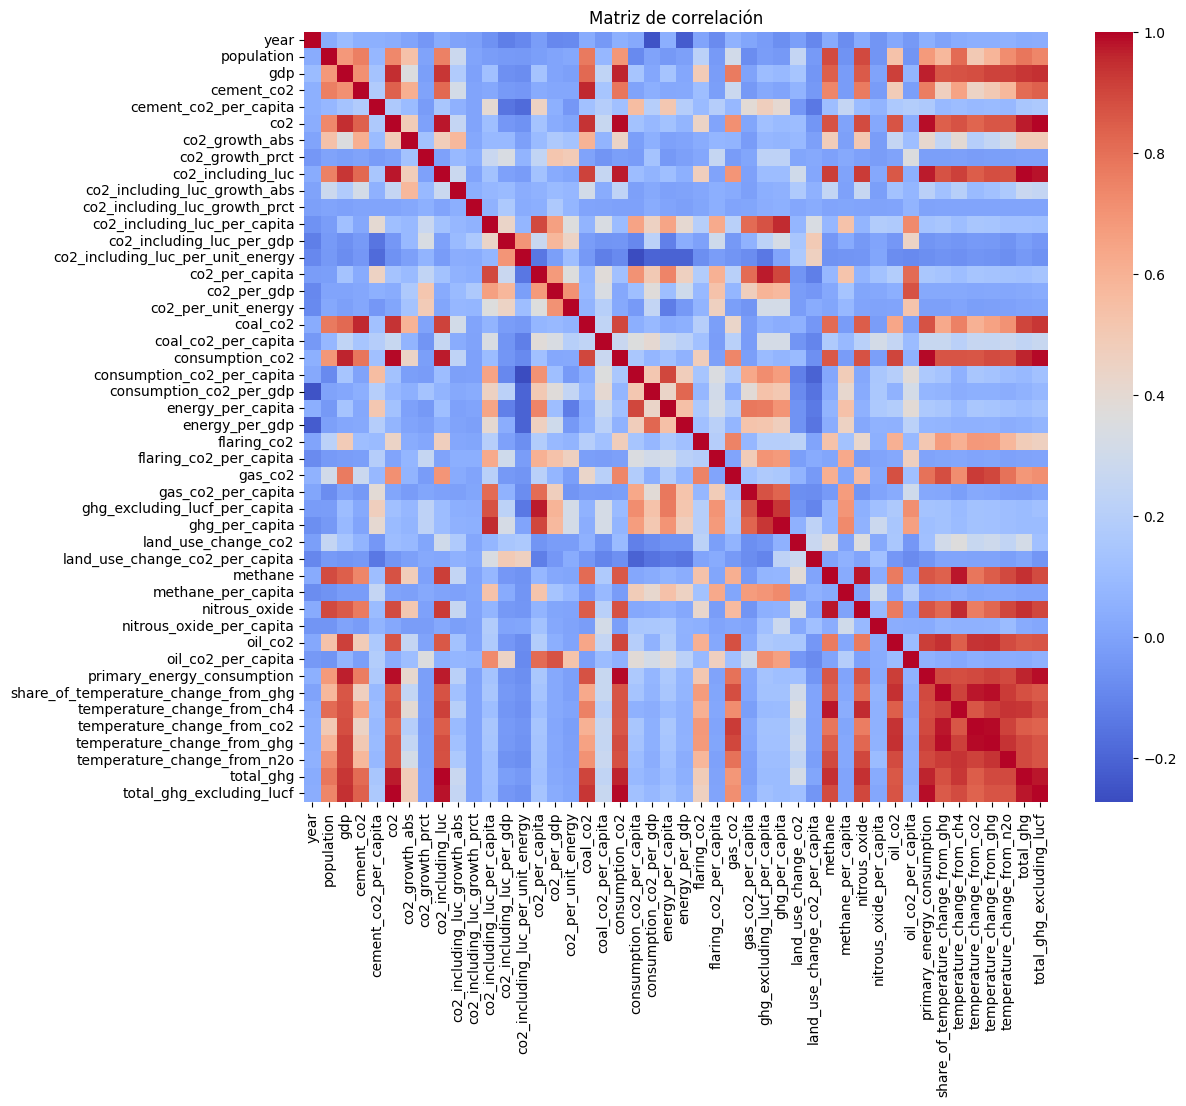

In [80]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Matriz de correlación")
plt.show()

In [83]:
corr['co2'].sort_values(ascending=False).head(10)

,co2
co2,1.000000
total_ghg_excluding_lucf,0.999342
consumption_co2,0.993112
primary_energy_consumption,0.987875
co2_including_luc,0.978677
total_ghg,0.973409
gdp,0.946031
coal_co2,0.935365
nitrous_oxide,0.888250
methane,0.875310


Graficos evolucion en el tiempo

In [87]:
top_paises = df_clean[df_clean['year'] == 2024] \
    .sort_values(by='population', ascending=False) \
    .head(10)['country']

top_paises

,country
21762,India
9933,China
48007,United States
21937,Indonesia
36060,Pakistan
33210,Nigeria
7212,Brazil
4789,Bangladesh
38314,Russia
14992,Ethiopia


In [88]:
df_top = df_clean[df_clean['country'].isin(top_paises)]

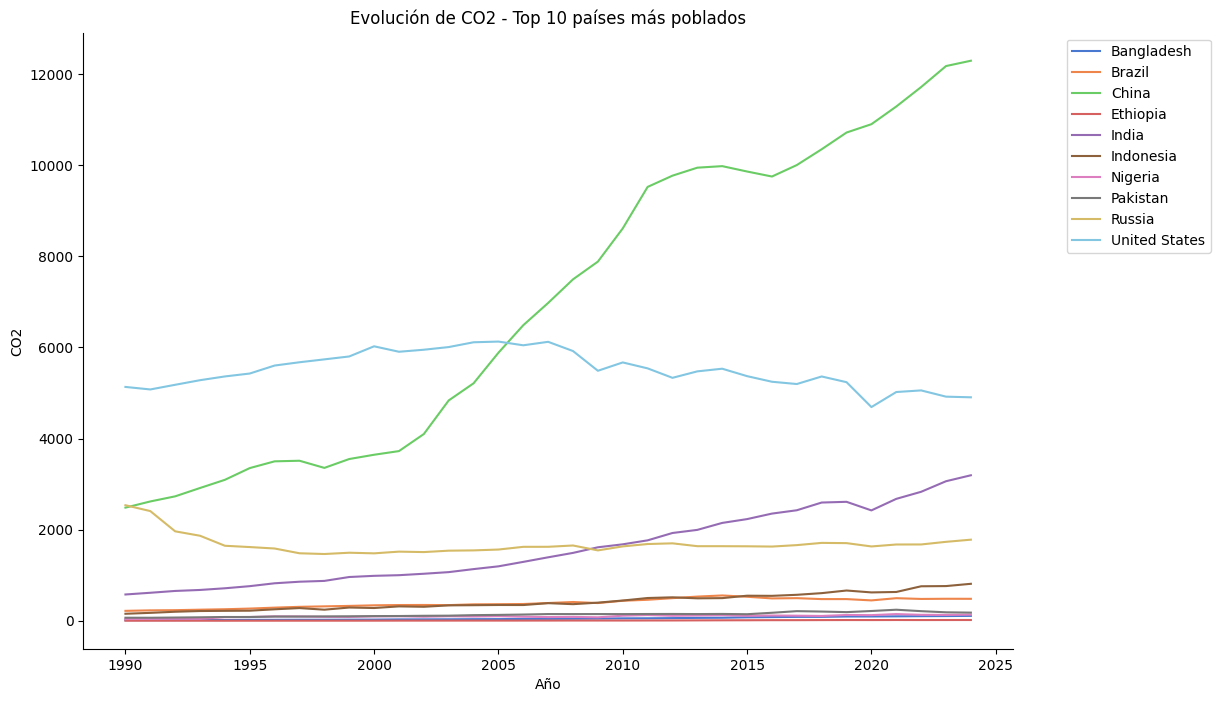

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.lineplot(
    data=df_top,
    x='year',
    y='co2',
    hue='country'
)

plt.title("Evolución de CO2 - Top 10 países más poblados")
plt.xlabel("Año")
plt.ylabel("CO2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

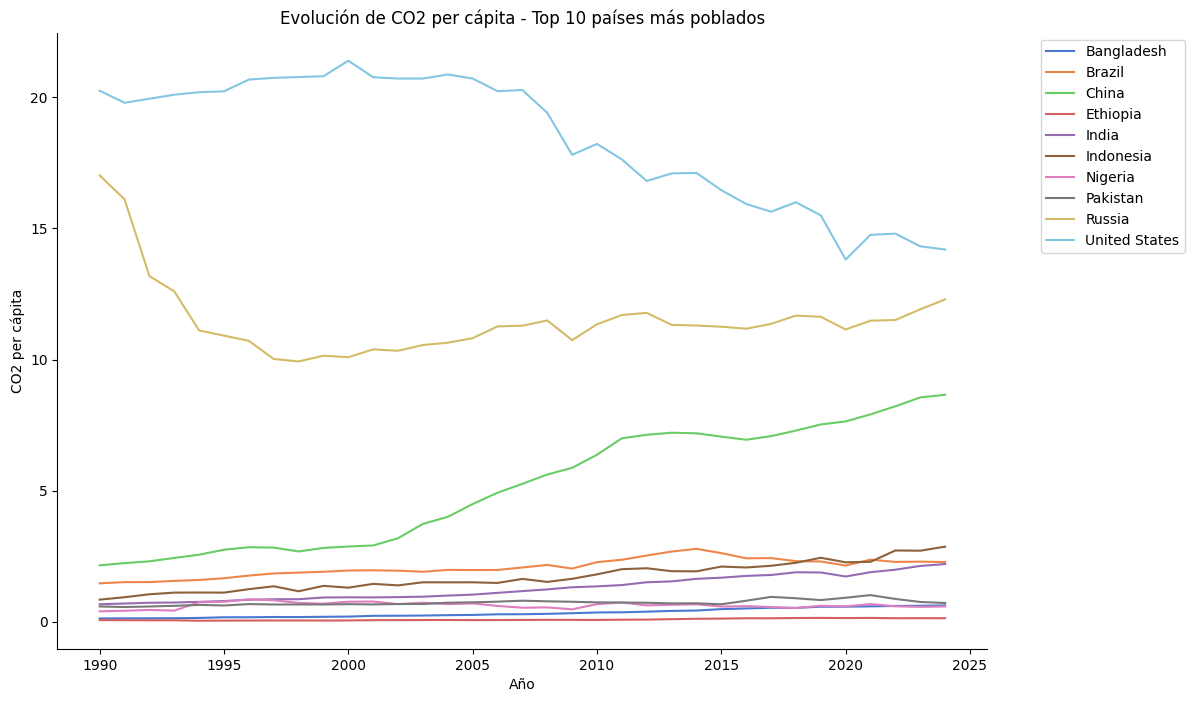

In [90]:
plt.figure(figsize=(12,8))

sns.lineplot(
    data=df_top,
    x='year',
    y='co2_per_capita',
    hue='country'
)

plt.title("Evolución de CO2 per cápita - Top 10 países más poblados")
plt.xlabel("Año")
plt.ylabel("CO2 per cápita")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [91]:
df_clean = df_clean.sort_values(['country', 'year'])

df_clean['co2_acumulado'] = df_clean.groupby('country')['co2'].cumsum()

In [92]:
ultimo_anio = df_clean['year'].max()

top_paises = df_clean[df_clean['year'] == ultimo_anio] \
    .sort_values(by='population', ascending=False) \
    .head(10)['country']

df_top = df_clean[df_clean['country'].isin(top_paises)]

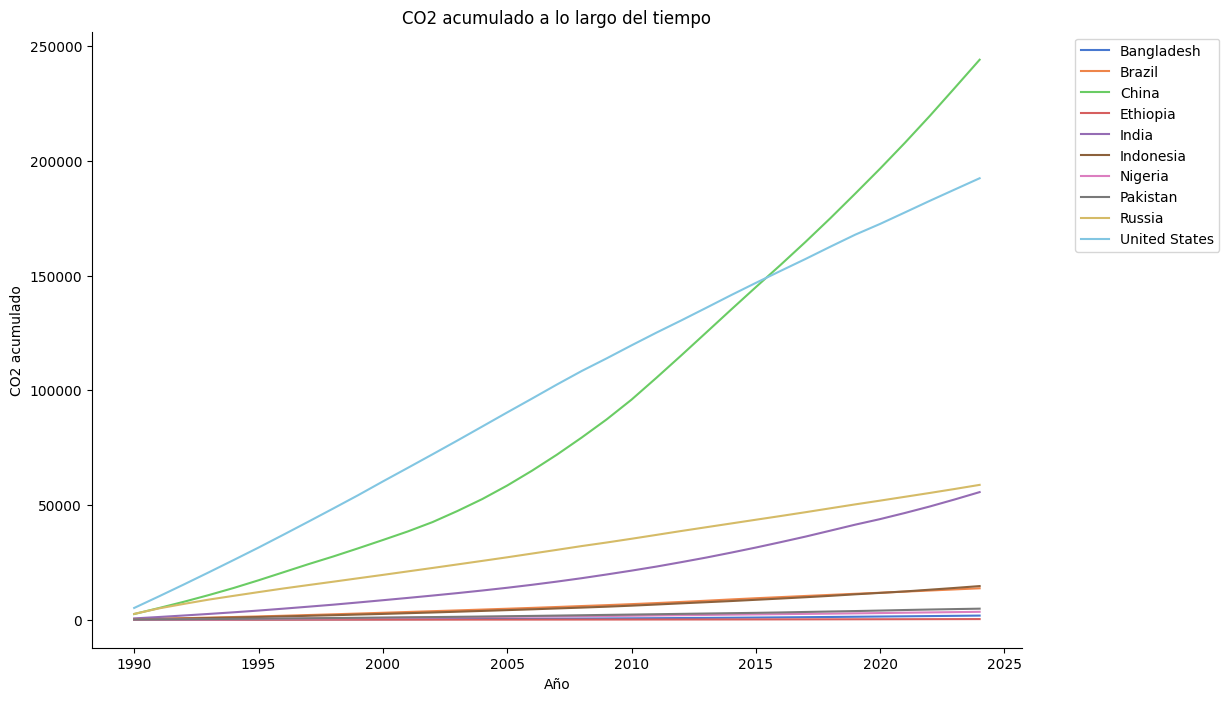

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.lineplot(
    data=df_top,
    x='year',
    y='co2_acumulado',
    hue='country'
)

plt.title("CO2 acumulado a lo largo del tiempo")
plt.ylabel("CO2 acumulado")
plt.xlabel("Año")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

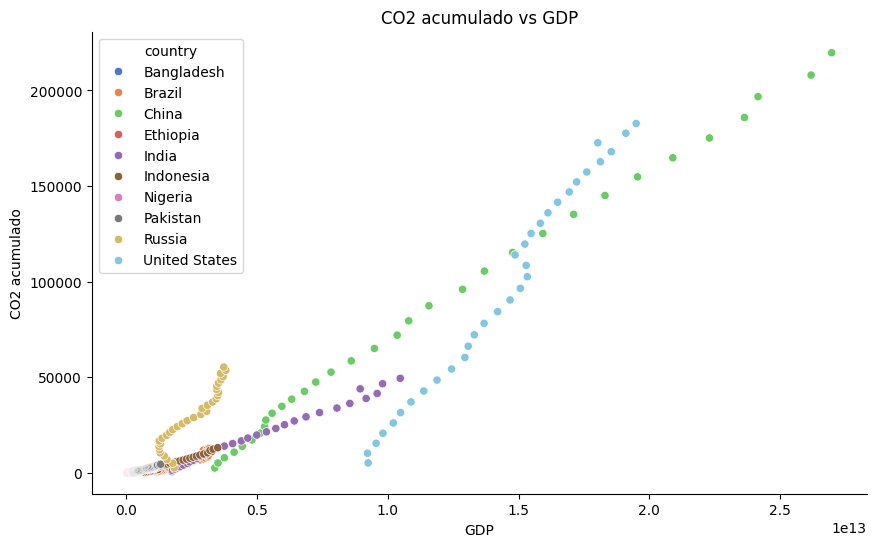

In [94]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_top,
    x='gdp',
    y='co2_acumulado',
    hue='country'
)

plt.title("CO2 acumulado vs GDP")
plt.xlabel("GDP")
plt.ylabel("CO2 acumulado")
plt.show()